# Phase 4 — SPC 관리도 구현
**핵심 파트**: Xbar-R, CUSUM, EWMA 관리도 + Nelson 8규칙 + 공정 능력 지수(Cp, Cpk)  
**적용 피처**: Chamber_Temperature, Vacuum_Pressure, RF_Power (우선 적용)

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from spc_utils import (
    xbar_r_chart, cusum_chart, ewma_chart,
    process_capability, nelson_rules,
    plot_xbar_r, plot_cusum, plot_ewma, nelson_summary_table
)
import warnings
warnings.filterwarnings('ignore')

matplotlib.rc('font', family='Malgun Gothic')
matplotlib.rcParams['axes.unicode_minus'] = False

DATA_PATH = '../data/semiconductor_quality_control.csv'
TARGET_COL = 'Defect'

# SPC 우선 적용 피처
SPC_FEATURES = ['Chamber_Temperature', 'Vacuum_Pressure', 'RF_Power']
ALL_FEATURES = [
    'Chamber_Temperature', 'Gas_Flow_Rate', 'RF_Power',
    'Etch_Depth', 'Rotation_Speed', 'Vacuum_Pressure',
    'Stage_Alignment_Error', 'Vibration_Level',
    'UV_Exposure_Intensity', 'Particle_Count'
]

In [2]:
df = pd.read_csv(DATA_PATH)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (4219, 16)


,Process_ID,Timestamp,Tool_Type,Wafer_ID,Chamber_Temperature,Gas_Flow_Rate,RF_Power,Etch_Depth,Rotation_Speed,Vacuum_Pressure,Stage_Alignment_Error,Vibration_Level,UV_Exposure_Intensity,Particle_Count,Defect,Join_Status
0,P1102,2025-07-01 00:00:00,Etching,WAF87755,80.200134,54.865333,287.864271,441.885329,1494.249617,0.513109,1.497935,0.007120,103.902639,800,0,Joining
1,P1270,2025-07-01 00:00:09,Etching,WAF62509,79.640360,53.168523,379.395772,566.863968,1245.578501,0.488671,1.562643,0.010686,116.836854,259,0,Joining
2,P1614,2025-07-01 00:00:24,Etching,WAF58402,72.900629,38.047432,404.027267,486.851721,1557.893248,0.524697,3.020189,0.004980,116.211215,407,0,Joining


## 1. Xbar-R 관리도 — 주요 3개 피처

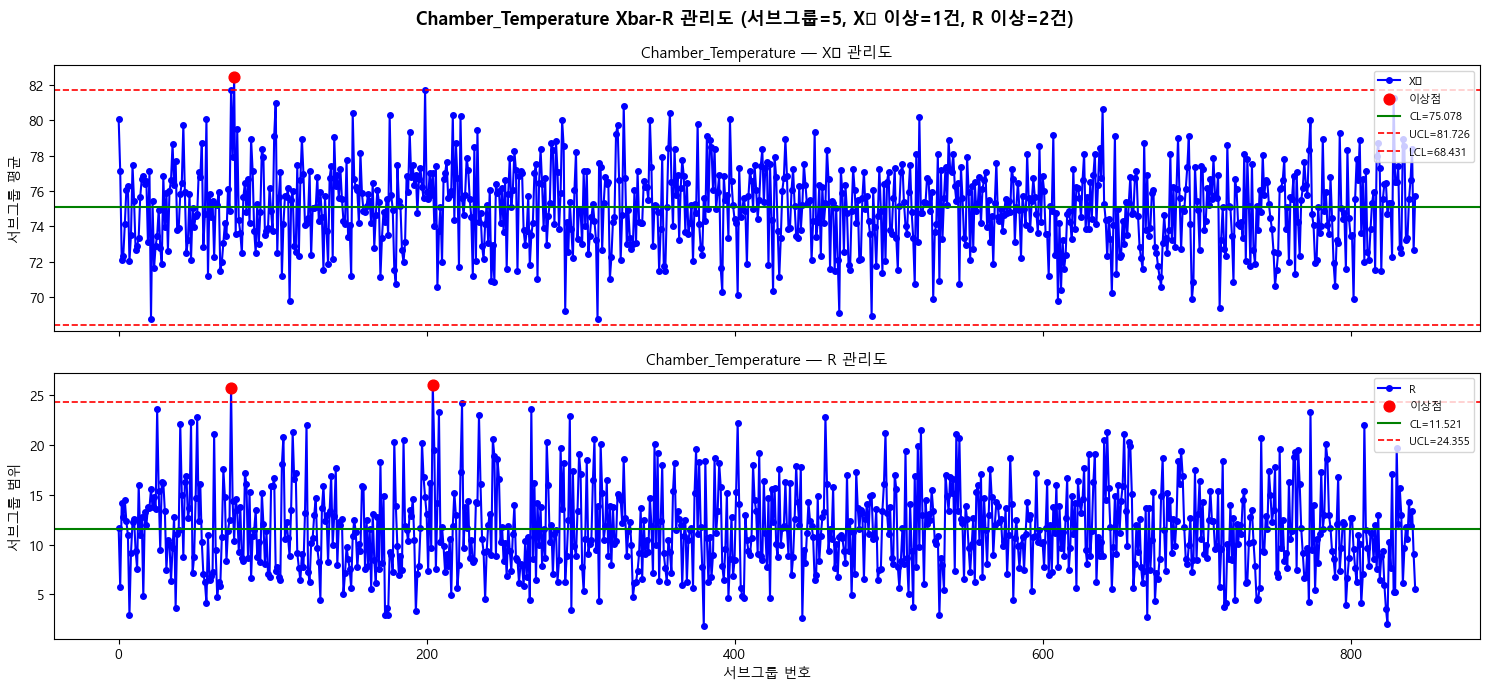

Chamber_Temperature: X̄ UCL=81.726, CL=75.078, LCL=68.431
        R UCL=24.355, CL=11.521



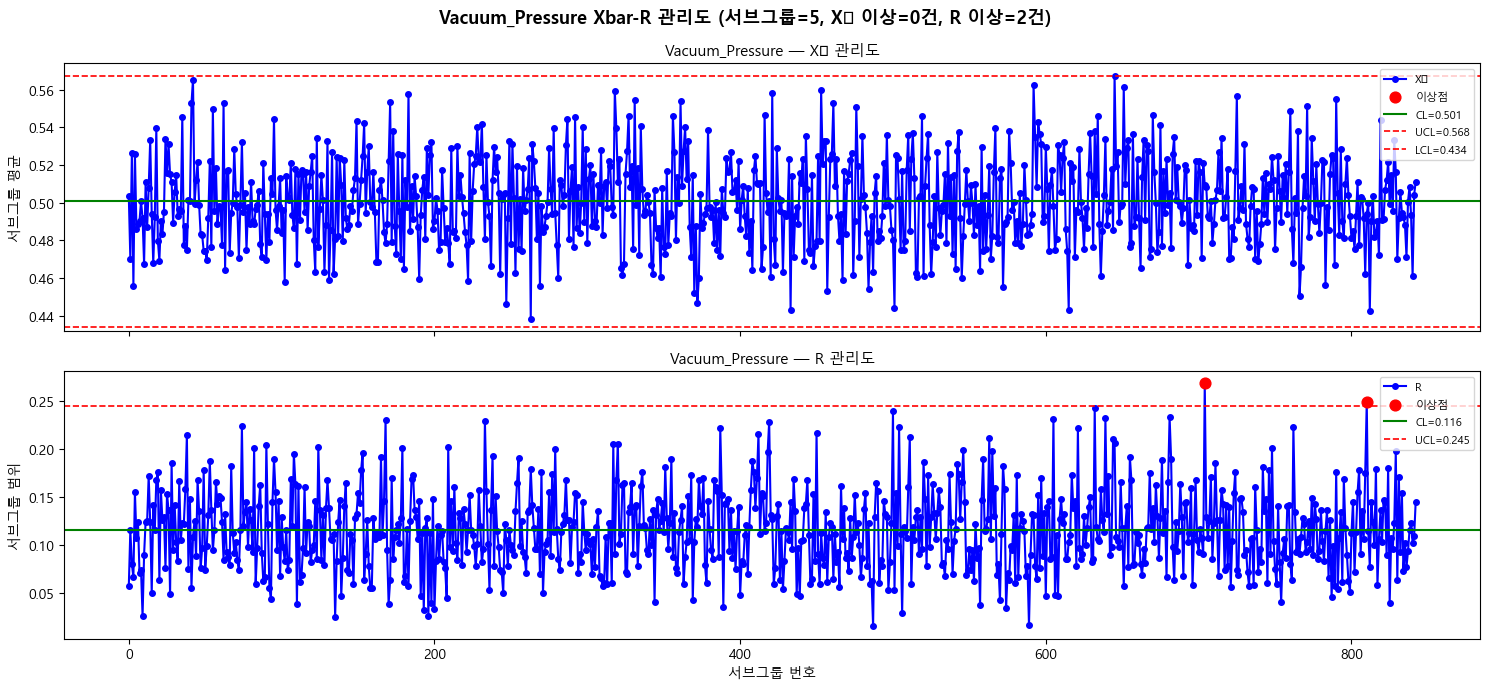

Vacuum_Pressure: X̄ UCL=0.568, CL=0.501, LCL=0.434
        R UCL=0.245, CL=0.116



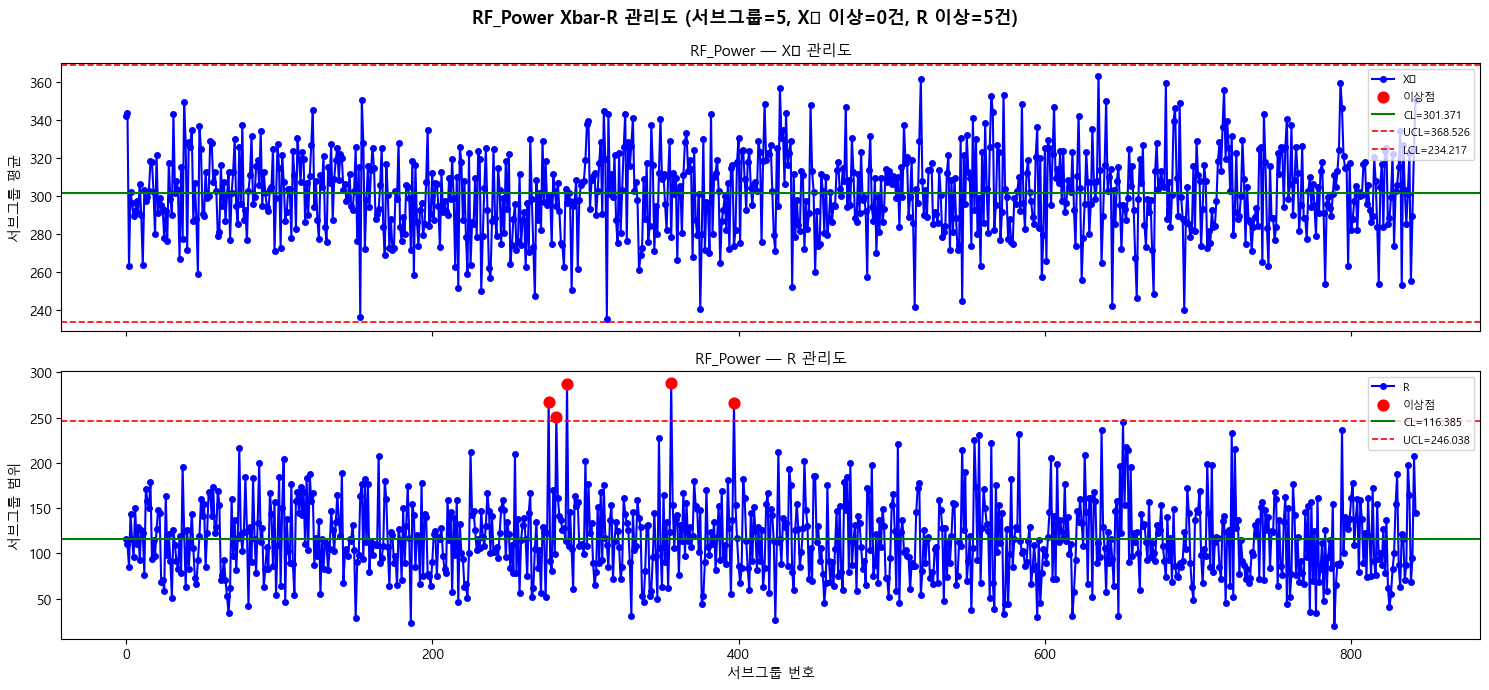

RF_Power: X̄ UCL=368.526, CL=301.371, LCL=234.217
        R UCL=246.038, CL=116.385



In [3]:
SUBGROUP_SIZE = 5

for feat in SPC_FEATURES:
    result = xbar_r_chart(df[feat], subgroup_size=SUBGROUP_SIZE)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
    plot_xbar_r(result, feat, ax1, ax2)

    n_viol_xbar = ((result['xbar'] > result['xbar_ucl']) | (result['xbar'] < result['xbar_lcl'])).sum()
    n_viol_r = (result['r'] > result['r_ucl']).sum()
    fig.suptitle(f'{feat} Xbar-R 관리도 (서브그룹={SUBGROUP_SIZE}, X̄ 이상={n_viol_xbar}건, R 이상={n_viol_r}건)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../data/spc_xbar_r_{feat}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'{feat}: X̄ UCL={result["xbar_ucl"]:.3f}, CL={result["xbar_cl"]:.3f}, LCL={result["xbar_lcl"]:.3f}')
    print(f'        R UCL={result["r_ucl"]:.3f}, CL={result["r_cl"]:.3f}')
    print()

## 2. CUSUM 관리도 — 소규모 드리프트 탐지

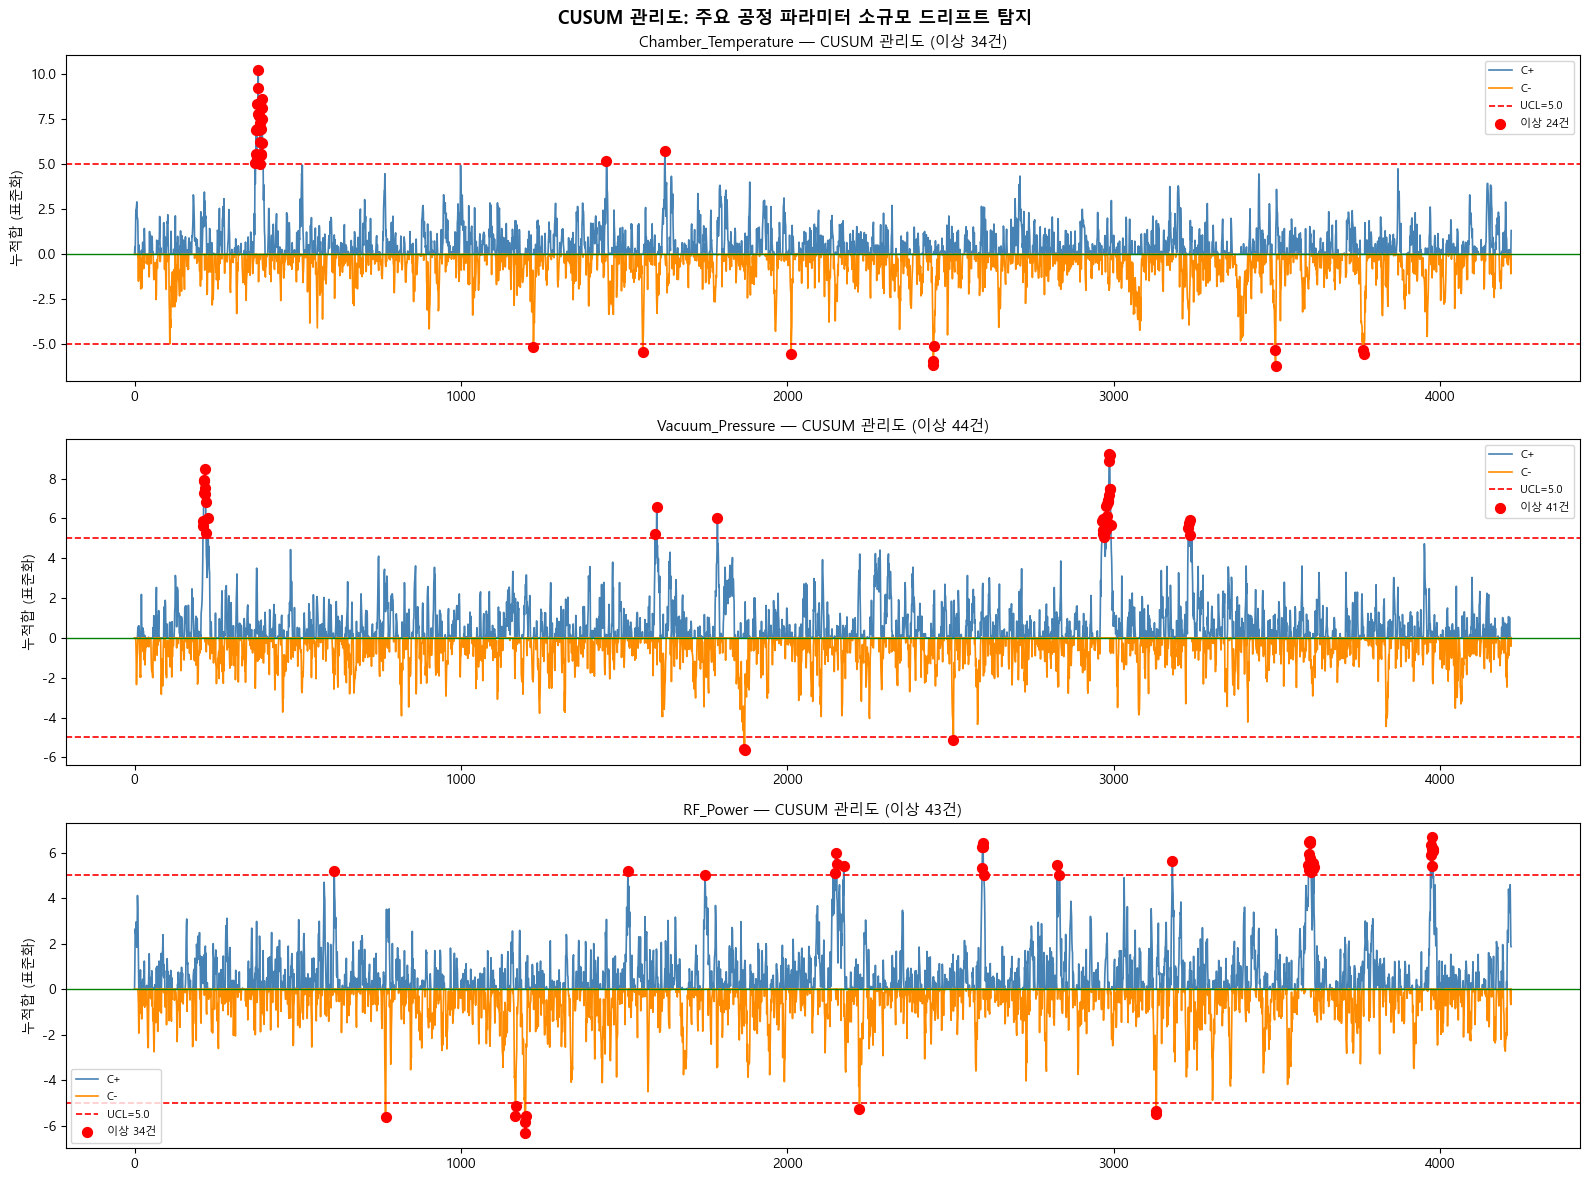

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

for i, feat in enumerate(SPC_FEATURES):
    result = cusum_chart(df[feat], k=0.5, h=5.0)
    plot_cusum(result, np.arange(len(df)), feat, axes[i])
    total_viol = len(result['violations_plus']) + len(result['violations_minus'])
    axes[i].set_title(f'{feat} — CUSUM 관리도 (이상 {total_viol}건)', fontsize=11)

plt.suptitle('CUSUM 관리도: 주요 공정 파라미터 소규모 드리프트 탐지', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/spc_cusum.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. EWMA 관리도 — 작은 변화 조기 탐지

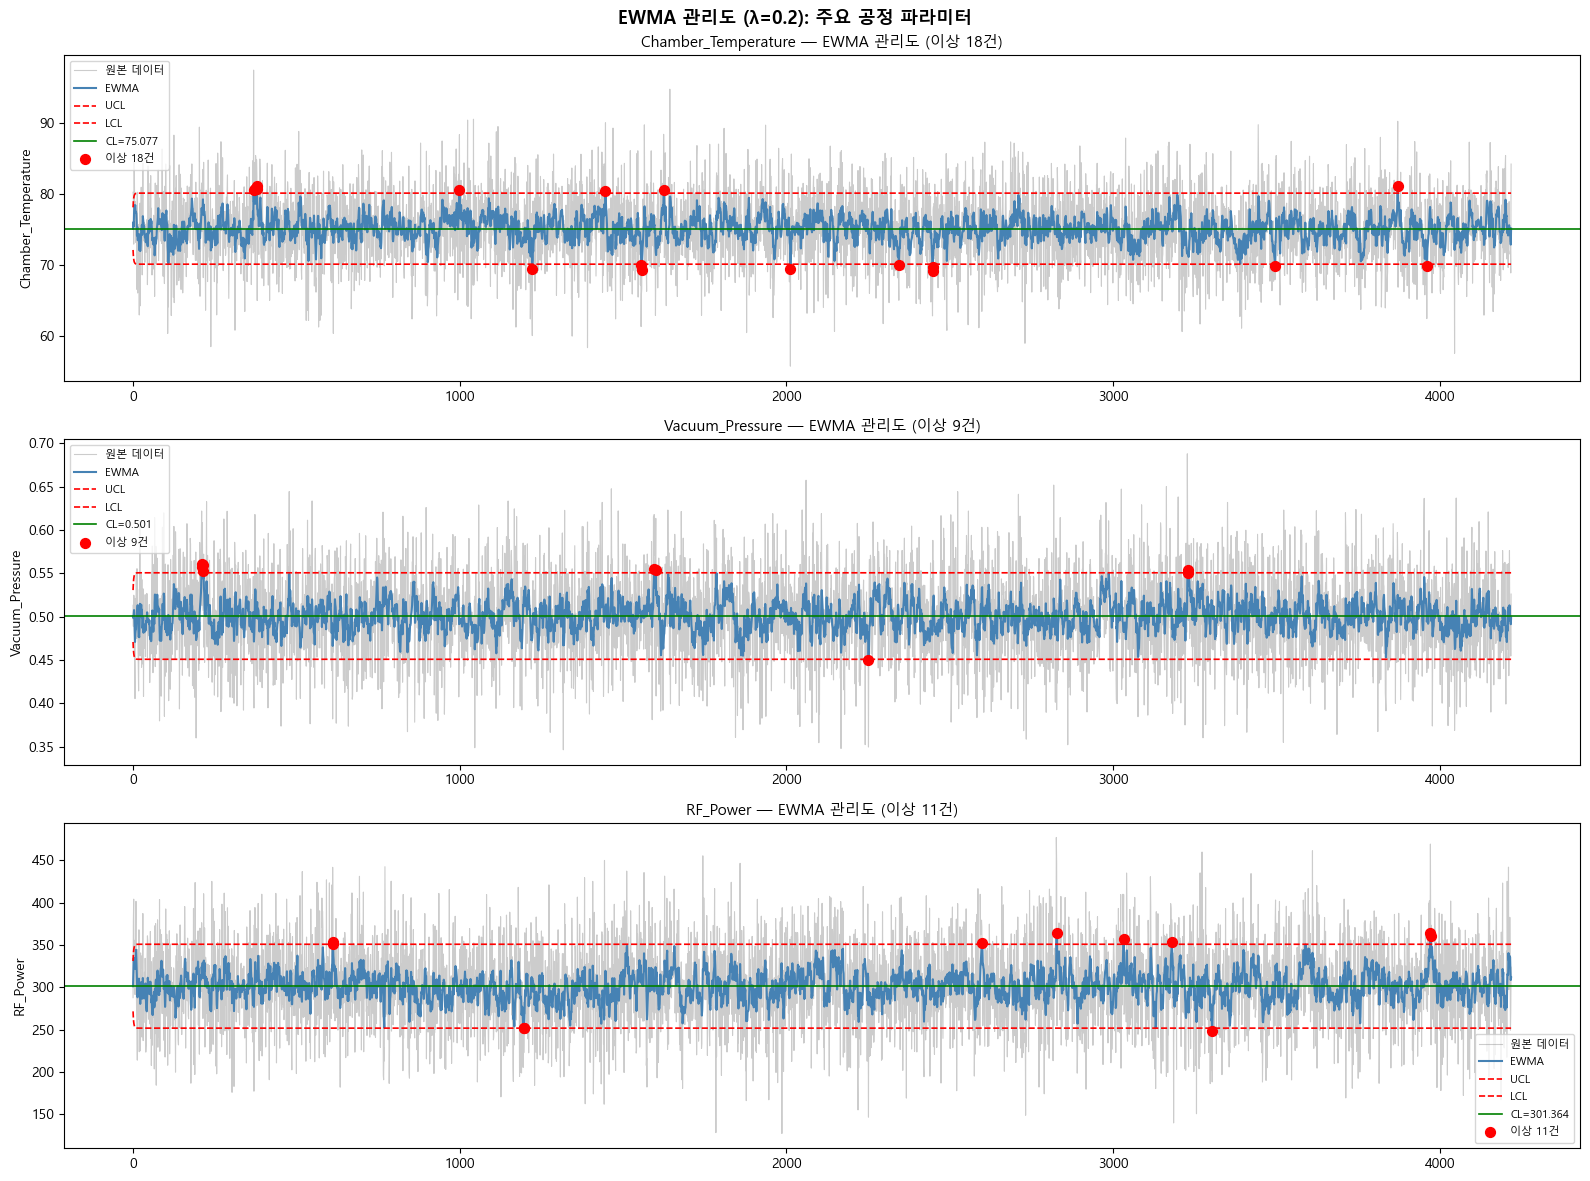

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

for i, feat in enumerate(SPC_FEATURES):
    result = ewma_chart(df[feat], lam=0.2, L=3.0)
    plot_ewma(result, df[feat], feat, axes[i])
    axes[i].set_title(f'{feat} — EWMA 관리도 (이상 {len(result["violations"])}건)', fontsize=11)

plt.suptitle('EWMA 관리도 (λ=0.2): 주요 공정 파라미터', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/spc_ewma.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 공정 능력 지수 (Cp, Cpk)

In [6]:
# 각 피처의 ±3σ를 공학적 규격 한계(USL/LSL)로 가정
# (실제 공정에서는 설계 규격을 사용해야 함)
capability_results = []

for feat in ALL_FEATURES:
    mu = df[feat].mean()
    sigma = df[feat].std()
    usl = mu + 3 * sigma  # 임시 공학 규격
    lsl = mu - 3 * sigma

    cap = process_capability(df[feat], usl=usl, lsl=lsl)
    capability_results.append({
        '피처': feat,
        'Cp': cap['cp'],
        'Cpk': cap['cpk'],
        '평균(μ)': cap['mu'],
        '표준편차(σ)': cap['sigma'],
        '판정': cap['interpretation']
    })

cap_df = pd.DataFrame(capability_results).set_index('피처')
print('공정 능력 지수 (Cp, Cpk) — ±3σ 규격 기준')
cap_df.style.format({'Cp': '{:.3f}', 'Cpk': '{:.3f}', '평균(μ)': '{:.3f}', '표준편차(σ)': '{:.3f}'})

공정 능력 지수 (Cp, Cpk) — ±3σ 규격 기준


,Cp,Cpk,평균(μ),표준편차(σ),판정
피처,,,,,
Chamber_Temperature,1.000,1.000,75.077,5.002,불량 (공정 불안정)
Gas_Flow_Rate,1.000,1.000,49.936,10.119,보통 (개선 필요)
RF_Power,1.000,1.000,301.364,49.479,보통 (개선 필요)
Etch_Depth,1.000,1.000,498.669,101.451,보통 (개선 필요)
Rotation_Speed,1.000,1.000,1504.745,202.833,보통 (개선 필요)
Vacuum_Pressure,1.000,1.000,0.501,0.050,보통 (개선 필요)
Stage_Alignment_Error,1.000,1.000,2.003,0.818,보통 (개선 필요)
Vibration_Level,1.000,1.000,0.010,0.005,보통 (개선 필요)
UV_Exposure_Intensity,1.000,1.000,119.930,15.057,보통 (개선 필요)


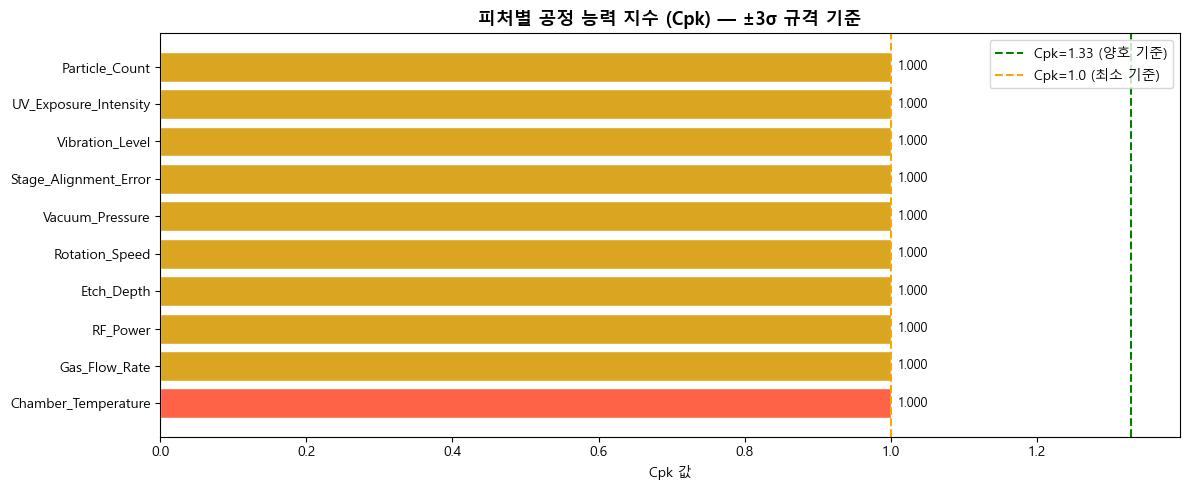

In [7]:
# Cpk 시각화
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['seagreen' if v >= 1.33 else ('goldenrod' if v >= 1.0 else 'tomato') for v in cap_df['Cpk']]
bars = ax.barh(cap_df.index, cap_df['Cpk'], color=colors, edgecolor='white')
ax.axvline(1.33, color='green', linestyle='--', linewidth=1.5, label='Cpk=1.33 (양호 기준)')
ax.axvline(1.0,  color='orange', linestyle='--', linewidth=1.5, label='Cpk=1.0 (최소 기준)')
for bar in bars:
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=9)
ax.set_xlabel('Cpk 값')
ax.set_title('피처별 공정 능력 지수 (Cpk) — ±3σ 규격 기준', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../data/spc_cpk.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Nelson 규칙 8가지 자동 탐지

In [8]:
print('Nelson 규칙 위반 탐지 결과')
print('=' * 70)

for feat in SPC_FEATURES:
    data = df[feat].values
    cl = data.mean()
    sigma = data.std()
    ucl = cl + 3 * sigma
    lcl = cl - 3 * sigma

    violations = nelson_rules(data, cl=cl, ucl=ucl, lcl=lcl)
    summary = nelson_summary_table(violations, n_total=len(data))

    print(f'\n[{feat}]')
    print(summary.to_string(index=False))

print('\n' + '=' * 70)

Nelson 규칙 위반 탐지 결과

[Chamber_Temperature]
           규칙  위반 건수 위반율 (%)                   위반 시점 (앞 5개)
   R1 (3σ 이탈)     12    0.3%   [238, 369, 1024, 1042, 1222]
   R2 (9점 편향)      8    0.2%  [335, 3597, 3891, 3892, 3893]
   R3 (6점 추세)     15    0.4%    [393, 411, 433, 1087, 1560]
  R4 (14점 교대)     18    0.4% [1074, 1273, 1274, 1275, 1276]
 R5 (2σ 2/3점)     10    0.2%  [108, 1222, 1223, 1726, 1727]
 R6 (1σ 4/5점)     31    0.7%      [342, 373, 375, 376, 379]
R7 (1σ 내 15점)     27    0.6%      [308, 309, 328, 329, 879]
 R8 (1σ 밖 8점)      0    0.0%                              -

[Vacuum_Pressure]
           규칙  위반 건수 위반율 (%)                   위반 시점 (앞 5개)
   R1 (3σ 이탈)      7    0.2% [1046, 1317, 2060, 2167, 2251]
   R2 (9점 편향)     15    0.4%      [212, 213, 214, 215, 216]
   R3 (6점 추세)     16    0.4%      [467, 563, 599, 618, 902]
  R4 (14점 교대)     17    0.4%  [108, 1514, 1515, 1516, 1517]
 R5 (2σ 2/3점)     10    0.2%  [212, 1595, 2101, 2962, 3146]
 R6 (1σ 4/5점)     13    0.3%      [212,

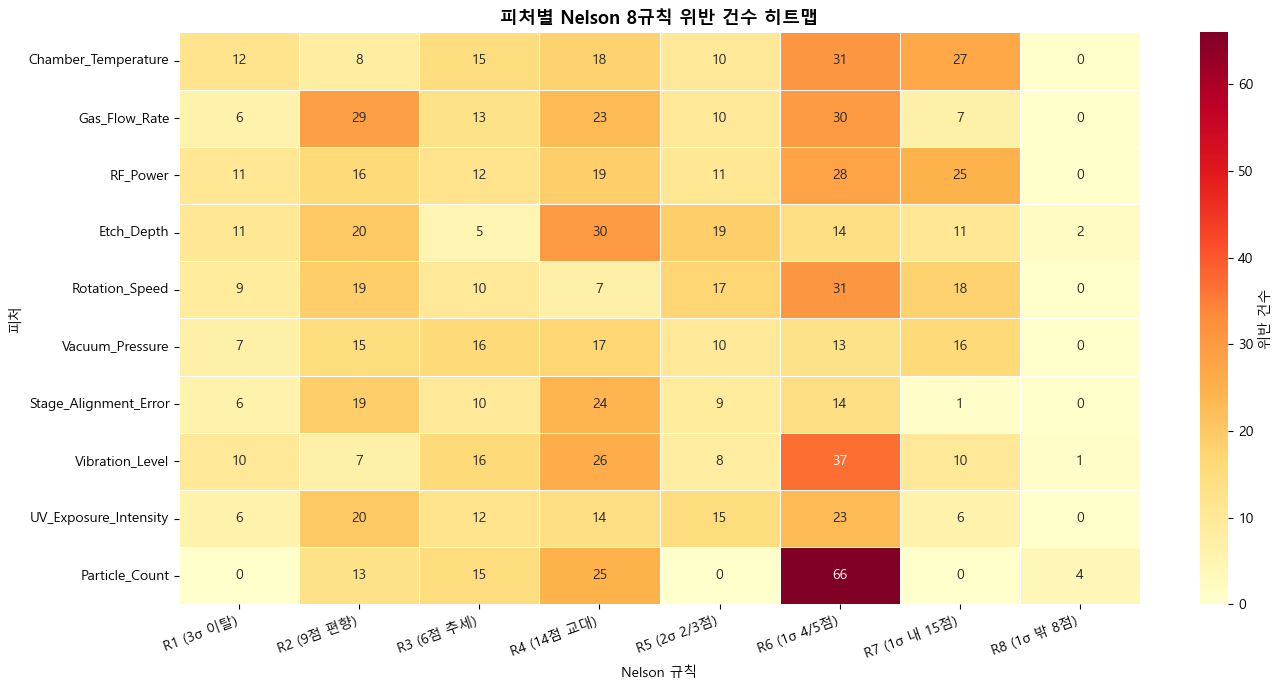

In [9]:
# Nelson 규칙 위반 건수 히트맵 (피처 × 규칙)
nelson_matrix = {}

for feat in ALL_FEATURES:
    data = df[feat].values
    cl = data.mean()
    sigma = data.std()
    ucl = cl + 3 * sigma
    lcl = cl - 3 * sigma
    violations = nelson_rules(data, cl=cl, ucl=ucl, lcl=lcl)
    nelson_matrix[feat] = {rule: len(pts) for rule, pts in violations.items()}

nelson_df = pd.DataFrame(nelson_matrix).T

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(nelson_df, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': '위반 건수'})
ax.set_title('피처별 Nelson 8규칙 위반 건수 히트맵', fontsize=13, fontweight='bold')
ax.set_xlabel('Nelson 규칙')
ax.set_ylabel('피처')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../data/spc_nelson_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Tool_Type별 SPC 비교 (Chamber_Temperature)

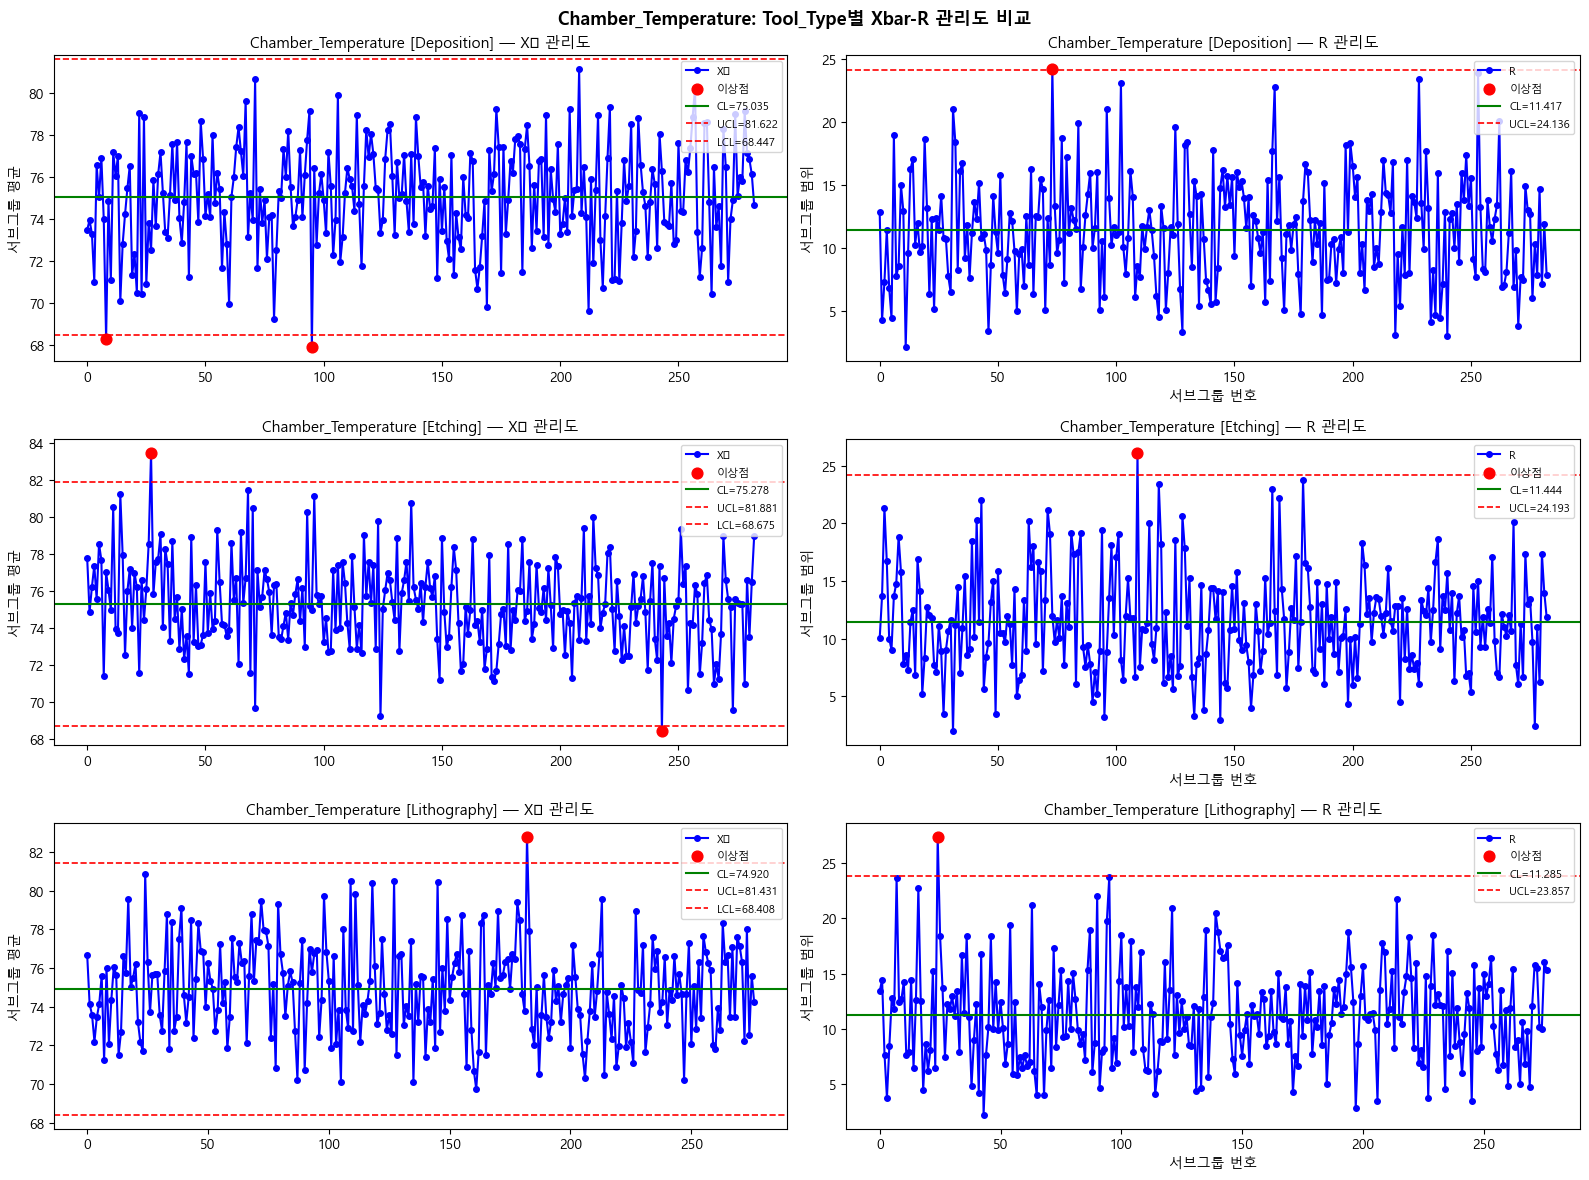

In [10]:
feat = 'Chamber_Temperature'
tool_types = df['Tool_Type'].unique()

fig, axes = plt.subplots(len(tool_types), 2, figsize=(16, 4 * len(tool_types)))

for i, tool in enumerate(sorted(tool_types)):
    subset = df[df['Tool_Type'] == tool][feat].reset_index(drop=True)
    result = xbar_r_chart(subset, subgroup_size=5)
    plot_xbar_r(result, f'{feat} [{tool}]', axes[i][0], axes[i][1])

plt.suptitle(f'{feat}: Tool_Type별 Xbar-R 관리도 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'../data/spc_tooltype_xbar_r_{feat}.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 이상 탐지 시점 vs 실제 불량 발생 시점 비교

Chamber_Temperature EWMA 이상 탐지: 18건
실제 불량 발생: 617건
동시 발생 (교집합): 5건
SPC → Defect 적중률: 27.8%
Defect 중 SPC 탐지: 0.8%


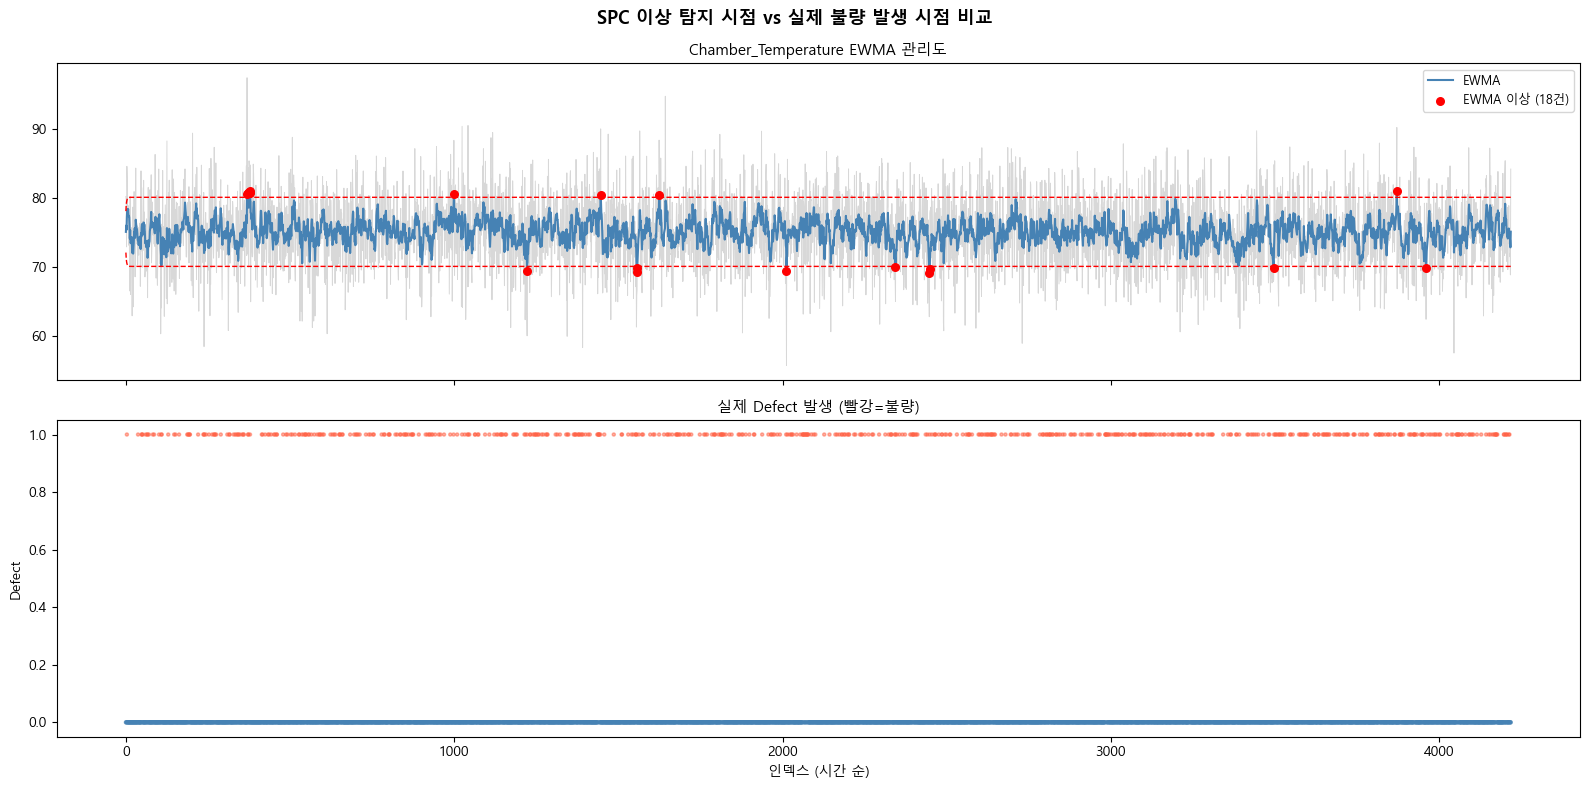

In [11]:
# EWMA 이상 탐지 시점과 Defect=1 시점 비교
feat = 'Chamber_Temperature'
result_ewma = ewma_chart(df[feat], lam=0.2, L=3.0)

defect_idx = df[df[TARGET_COL] == 1].index.tolist()
ewma_viol_idx = result_ewma['violations'].tolist()

# 이상 탐지 vs 불량 일치율
both = set(defect_idx) & set(ewma_viol_idx)
print(f'{feat} EWMA 이상 탐지: {len(ewma_viol_idx)}건')
print(f'실제 불량 발생: {len(defect_idx)}건')
print(f'동시 발생 (교집합): {len(both)}건')
print(f'SPC → Defect 적중률: {len(both)/len(ewma_viol_idx)*100:.1f}%')
print(f'Defect 중 SPC 탐지: {len(both)/len(defect_idx)*100:.1f}%')

# 시각화
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(df.index, df[feat].values, 'gray', alpha=0.3, linewidth=0.7)
axes[0].plot(df.index, result_ewma['ewma'], 'steelblue', linewidth=1.5, label='EWMA')
axes[0].plot(df.index, result_ewma['ucl'], 'r--', linewidth=1)
axes[0].plot(df.index, result_ewma['lcl'], 'r--', linewidth=1)
axes[0].scatter(ewma_viol_idx, result_ewma['ewma'][ewma_viol_idx],
                color='red', s=30, zorder=5, label=f'EWMA 이상 ({len(ewma_viol_idx)}건)')
axes[0].set_title(f'{feat} EWMA 관리도', fontsize=11)
axes[0].legend(fontsize=9)

axes[1].scatter(df.index, df[TARGET_COL], c=df[TARGET_COL].map({0: 'steelblue', 1: 'tomato'}),
                s=5, alpha=0.5)
axes[1].set_title('실제 Defect 발생 (빨강=불량)', fontsize=11)
axes[1].set_xlabel('인덱스 (시간 순)')
axes[1].set_ylabel('Defect')

plt.suptitle('SPC 이상 탐지 시점 vs 실제 불량 발생 시점 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/spc_vs_defect.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Phase 4 인사이트 요약

In [12]:
print('=' * 65)
print('Phase 4 SPC 관리도 분석 — 핵심 인사이트')
print('=' * 65)
print('''
1. Xbar-R 관리도
   - 서브그룹 크기 5로 공정 평균/범위 관리
   - 이상점 발생 시 공정 변동 증가 신호 포착 가능

2. CUSUM 관리도 (k=0.5, h=5)
   - Xbar-R보다 작은 공정 이동(drift) 조기 탐지
   - 드리프트가 누적될 때 경보 발생 → 예방 조치 시점 확인

3. EWMA 관리도 (λ=0.2)
   - 지수 가중 이동평균으로 최근 데이터에 더 많은 가중치
   - 단기 변동에 강건하면서도 추세 변화에 민감

4. 공정 능력 지수 (Cp, Cpk)
   - 실제 공정 규격(USL/LSL)이 없어 ±3σ 기준 사용
   - Cpk >= 1.33 기준으로 공정 안정성 판단

5. Nelson 규칙
   - 단순 관리 한계 이탈 외 추세/편향/교대 패턴 자동 탐지
   - 히트맵으로 어떤 피처가 어떤 규칙을 위반하는지 한눈에 파악

6. SPC vs 실제 불량
   - SPC 관리도는 공정 이상 탐지 도구 (원인 기반)
   - ML 모델은 패턴 학습 기반 불량 예측 도구
   - 두 접근법의 상호 보완성 → Phase 5에서 비교 분석
''')
print('=' * 65)

Phase 4 SPC 관리도 분석 — 핵심 인사이트

1. Xbar-R 관리도
   - 서브그룹 크기 5로 공정 평균/범위 관리
   - 이상점 발생 시 공정 변동 증가 신호 포착 가능

2. CUSUM 관리도 (k=0.5, h=5)
   - Xbar-R보다 작은 공정 이동(drift) 조기 탐지
   - 드리프트가 누적될 때 경보 발생 → 예방 조치 시점 확인

3. EWMA 관리도 (λ=0.2)
   - 지수 가중 이동평균으로 최근 데이터에 더 많은 가중치
   - 단기 변동에 강건하면서도 추세 변화에 민감

4. 공정 능력 지수 (Cp, Cpk)
   - 실제 공정 규격(USL/LSL)이 없어 ±3σ 기준 사용
   - Cpk >= 1.33 기준으로 공정 안정성 판단

5. Nelson 규칙
   - 단순 관리 한계 이탈 외 추세/편향/교대 패턴 자동 탐지
   - 히트맵으로 어떤 피처가 어떤 규칙을 위반하는지 한눈에 파악

6. SPC vs 실제 불량
   - SPC 관리도는 공정 이상 탐지 도구 (원인 기반)
   - ML 모델은 패턴 학습 기반 불량 예측 도구
   - 두 접근법의 상호 보완성 → Phase 5에서 비교 분석

